# Decision Tree Classifier

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Load data

In [30]:
df = pd.read_csv("Telco-Customer-Churn.csv")  # download from Kaggle

### 🧹 Data Preprocessing

In [31]:
# Drop unnecessary column
df.drop('customerID', axis=1, inplace=True)

# Handle missing values
df.fillna(df.mode().iloc[0], inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


### Features & Target

In [32]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Model Training

In [33]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 📊 Evaluation

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8019872249822569
Confusion Matrix:
 [[952  70]
 [209 178]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87      1022
           1       0.72      0.46      0.56       387

    accuracy                           0.80      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### Feature Importance:

In [35]:
print(model.feature_importances_)

[0.         0.00593728 0.         0.         0.15607786 0.00579171
 0.         0.08435983 0.12561831 0.         0.         0.
 0.         0.00224464 0.53772474 0.         0.0044847  0.0604598
 0.01730113]


### Tree Visualization

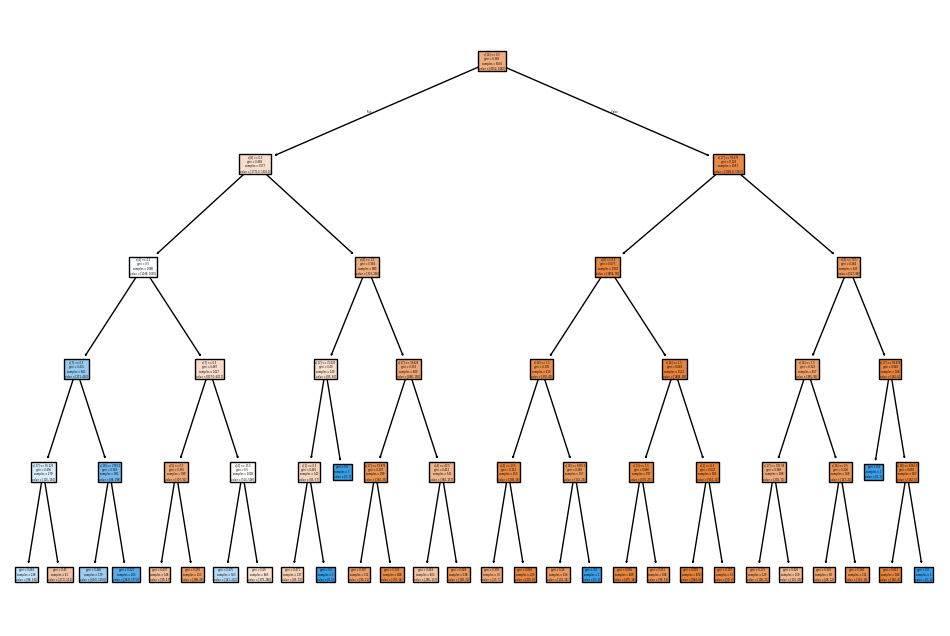

In [36]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

# Decision Tree Regressor

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [38]:
df = pd.read_csv("HousePricePrediction.csv") 

### Data Preprocessing

In [39]:
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


### Features & Target

In [40]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Model Training

In [41]:
model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Evaluation

In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 18386.317905745578
RMSE: 34447.85128322228


### Feature Importance:

In [43]:
print(model.feature_importances_)

[0.33812462 0.03139404 0.00125194 0.06608807 0.         0.00656999
 0.02185934 0.12996862 0.03022539 0.02484154 0.         0.34967646]


### Tree Visualization

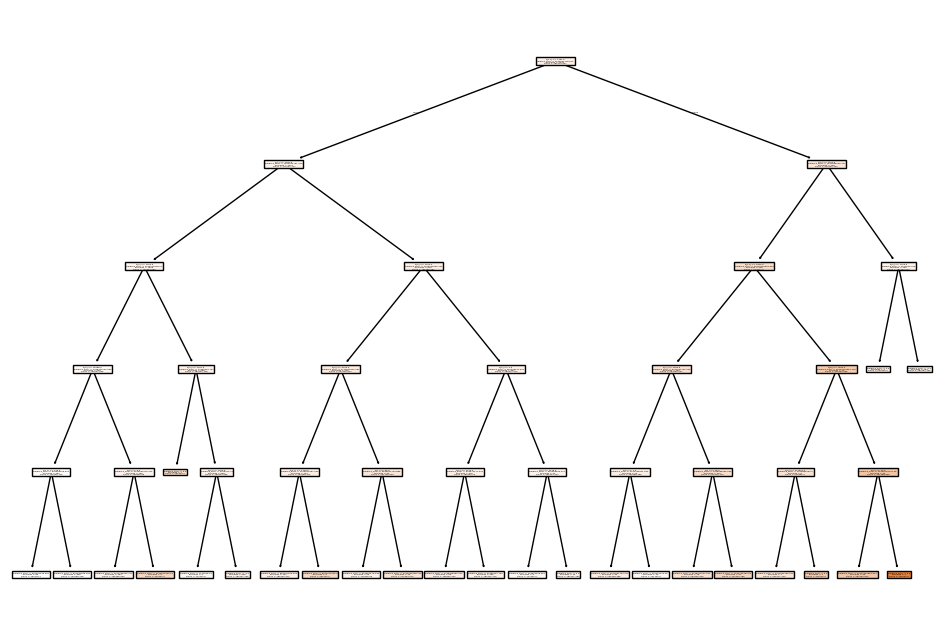

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()